### Library Installation

This cell installs the required Python libraries for the analysis, including data manipulation, network analysis, and visualization tools.

In [ ]:
!pip install pandas networkx matplotlib seaborn -q

### Importing Libraries

This section imports all the necessary libraries used throughout the analysis:
- `pandas` for data handling
- `networkx` for network analysis
- `matplotlib` and `seaborn` for visualization
- `numpy` for numerical operations
- additional utilities for graph metrics and processing

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from google.colab import drive
from networkx.algorithms.community import greedy_modularity_communities

### Data Loading and Setup

This cell mounts Google Drive and defines the file paths used in the project.  
The dataset containing the network edges is then loaded into a pandas DataFrame.

In [ ]:
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/SMA_Loreti_Pegoraro'
DATA_EDGES = f'{DRIVE_BASE}/Data/reddit_network_edges.csv'
VIZ_DIR = f'{DRIVE_BASE}/Visualizations'

edges_df = pd.read_csv(DATA_EDGES)
print(f'Loaded bows: {len(edges_df)}')
print(edges_df.head())

Mounted at /content/drive
Loaded bows: 20699
                 source                target  post_id subreddit  \
0            keyser1981      EnvironmentalWar  1q163rv  olympics   
1   Zestyclose_Ant_3039  JazzlikeTradition436  1q163rv  olympics   
2      EnvironmentalWar  JazzlikeTradition436  1q163rv  olympics   
3  JazzlikeTradition436                 PBS80  1q163rv  olympics   
4  JazzlikeTradition436          manuelmay887  1q163rv  olympics   

               type  
0  reply_to_comment  
1  reply_to_comment  
2     reply_to_post  
3  reply_to_comment  
4  reply_to_comment  


### Graph Construction

A directed graph is created using NetworkX.  
Edges are added from the dataset, and weights are assigned to represent the number of interactions between users.

In [ ]:
G = nx.DiGraph()

for _, row in edges_df.iterrows():
    s, t = row['source'], row['target']
    if G.has_edge(s, t):
        G[s][t]['weight'] += 1
    else:
        G.add_edge(s, t, weight=1, subreddit=row['subreddit'])

print('\n-- Graph Statistics --')
print(f'Nodes (users)  : {G.number_of_nodes()}')
print(f'Arches  : {G.number_of_edges()}')
print(f'Density  : {nx.density(G):.6f}')


-- Graph Statistics --
Nodes (users)  : 8698
Arches          : 16996
Density        : 0.000225


### Graph Connectivity Check

The directed graph is converted into an undirected version to verify whether it is fully connected.

In [ ]:
G_und = G.to_undirected()
print(f'Is connected (und): {nx.is_connected(G_und)}')

Is connected (und): False


### Largest Connected Component

Since real-world networks are often disconnected, this cell extracts the largest connected component of the graph for further analysis.

In [ ]:
largest_cc = max(nx.connected_components(G_und), key=len)
G_main = G_und.subgraph(largest_cc).copy()
print(f'Main component nodes : {G_main.number_of_nodes()}')
print(f'Main component arches: {G_main.number_of_edges()}')

Main component nodes : 8372
Main component arches: 14188


### Centrality Measures

This section introduces the computation of centrality metrics to identify the most important nodes in the network.

### Degree Centrality

In-degree and out-degree values are computed for each node, considering edge weights.

In [ ]:
in_deg  = dict(G.in_degree(weight='weight'))
out_deg = dict(G.out_degree(weight='weight'))

### Betweenness Centrality

This metric estimates how often a node lies on the shortest paths between other nodes.  
An approximate method is used to improve computational efficiency.

In [ ]:
betweenness = nx.betweenness_centrality(G_main, normalized=True, weight='weight', k=500)

### PageRank Computation

PageRank is calculated to measure node importance based on the structure of incoming links, using a damping factor.

In [ ]:
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)

### Centrality Data Aggregation

All computed centrality measures are combined into a single DataFrame for easier analysis and comparison.

In [ ]:
centrality_df = pd.DataFrame({
    'user'    : list(G.nodes()),
    'in_degree'   : [in_deg.get(n, 0) for n in G.nodes()],
    'out_degree'  : [out_deg.get(n, 0) for n in G.nodes()],
    'betweenness' : [betweenness.get(n, 0) for n in G.nodes()],
    'pagerank' : [pagerank.get(n, 0) for n in G.nodes()],
}).sort_values('pagerank', ascending=False)

print('\nTop 10 Users by PageRank (Most Influential):')
print(centrality_df.head(10).to_string(index=False))

centrality_df.to_csv(f'{DRIVE_BASE}/Data/centrality_measures.csv', index=False)
print('Saved: centrality_measures.csv')


Top 10 Users by PageRank (Most Influential):
                user  in_degree  out_degree  betweenness  pagerank
      Fun_With_Forks       1185           5     0.145436  0.028318
          FliryVorru        449           3     0.094413  0.019700
 SpiritualWatermelon          6           8     0.000134  0.012707
Chemical-Ocelot-9105         26          29     0.001743  0.009582
           Chickatey        299           3     0.081748  0.009386
       thisisntmyday         23          35     0.010223  0.007300
JazzlikeTradition436         89         124     0.040604  0.007227
        LordZZZ12345        252           2     0.048208  0.006694
      looneylooser24        158          12     0.041323  0.006274
         summerjoe45        201           6     0.038742  0.005937
Saved: centrality_measures.csv


### Top Users Visualization

This cell identifies and visualizes the top 15 users according to:
- in-degree
- PageRank

The results are displayed using bar plots.

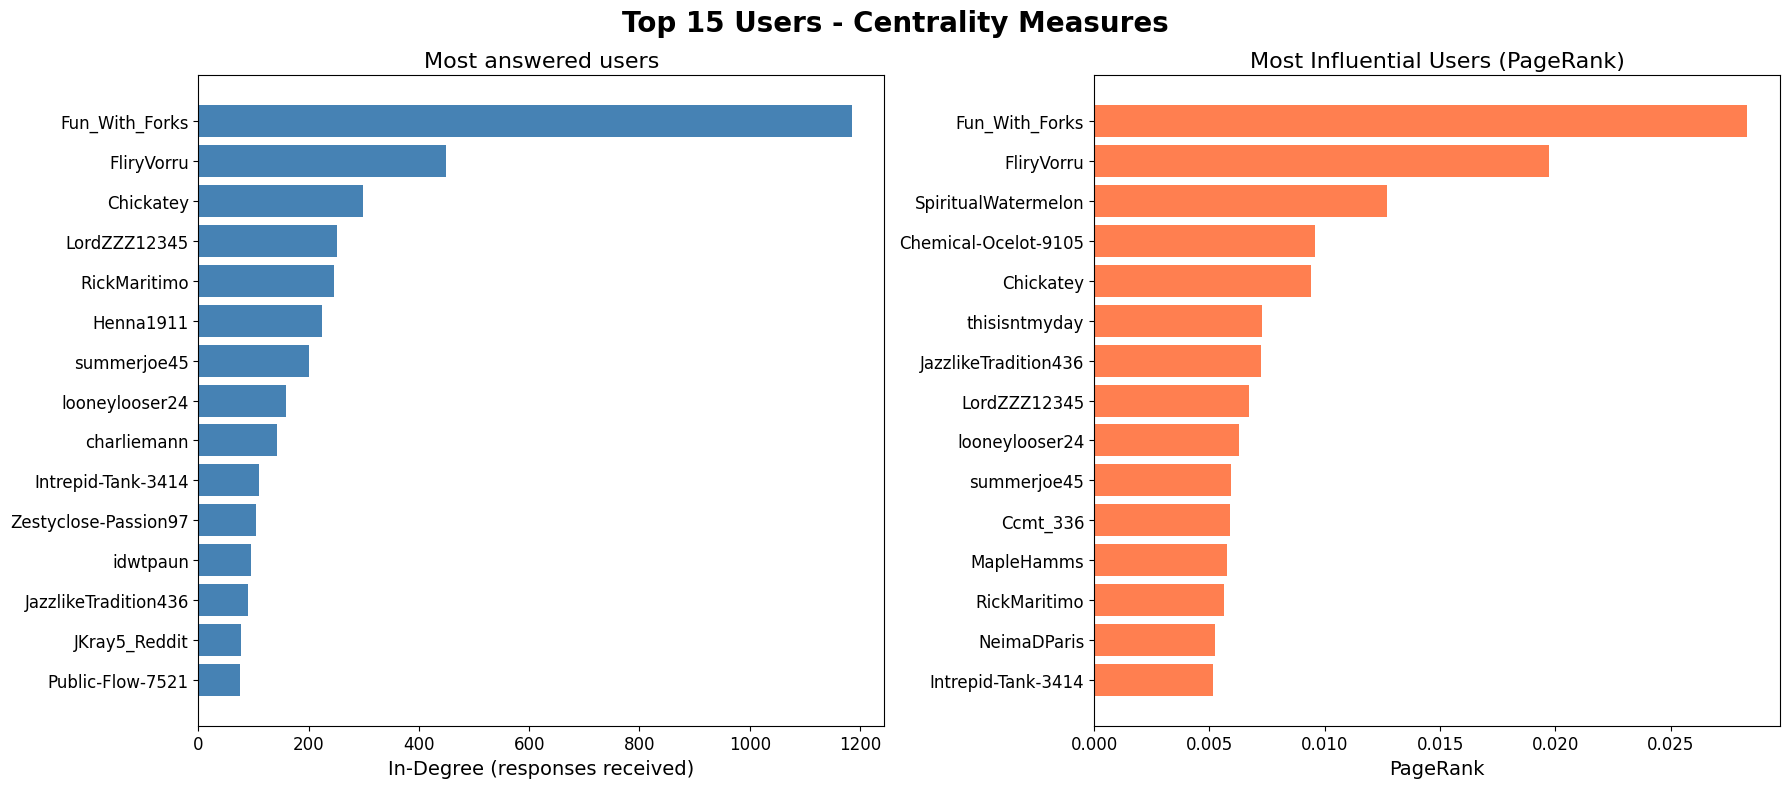

Saved: centrality_top15.png


In [ ]:
top15_id = centrality_df.nlargest(15, 'in_degree')
top15_pr = centrality_df.nlargest(15, 'pagerank')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 15 Users - Centrality Measures', fontsize=20, fontweight='bold')

# Left plot - In-degree
axes[0].barh(top15_id['user'], top15_id['in_degree'], color='steelblue')
axes[0].set_xlabel('In-Degree (responses received)', fontsize=14)
axes[0].set_title('Most answered users', fontsize=16)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].invert_yaxis()

# Right plot - PageRank
axes[1].barh(top15_pr['user'], top15_pr['pagerank'], color='coral')
axes[1].set_xlabel('PageRank', fontsize=14)
axes[1].set_title('Most Influential Users (PageRank)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/centrality_top15.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: centrality_top15.png')

### Community Detection

Communities are detected using the Greedy Modularity algorithm.  
Each node is assigned to a community based on network structure.

In [ ]:


communities_nx = list(greedy_modularity_communities(G_main, weight='weight'))

partition = {}
for comm_id, comm_nodes in enumerate(communities_nx):
    for node in comm_nodes:
        partition[node] = comm_id

num_communities = len(communities_nx)
comm_sizes = Counter(partition.values())

print(f'Communities detected: {num_communities}')
print('Community Size (Top 10):')
for comm_id, size in comm_sizes.most_common(10):
    print(f'  Community {comm_id}: {size} users')

Communities detected: 74
Community Size (Top 10):
  Community 0: 1965 users
  Community 1: 1107 users
  Community 2: 768 users
  Community 3: 696 users
  Community 4: 569 users
  Community 5: 555 users
  Community 6: 431 users
  Community 7: 252 users
  Community 8: 165 users
  Community 9: 140 users


### Modularity Evaluation

The modularity score is computed to evaluate the quality of the detected community structure.

In [ ]:
modularity = nx.community.modularity(G_main, communities_nx, weight='weight')
print(f'\nModularity: {modularity:.4f}')


Modularity: 0.7920


### Export Community Assignments

The detected community labels for each user are saved to a CSV file for further analysis.

In [ ]:
partition_df = pd.DataFrame([
    {'user': user, 'community': comm}
    for user, comm in partition.items()
])
partition_df.to_csv(f'{DRIVE_BASE}/Data/community_partition.csv', index=False)
print('Saved: community_partition.csv')


Saved: community_partition.csv


### User Subreddit Profiling

Each user is associated with their most frequent subreddit based on interaction data.

In [ ]:
user_subreddit = (
    edges_df.groupby('source')['subreddit']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'source': 'user', 'subreddit': 'main_subreddit'})
)
partition_enriched = partition_df.merge(user_subreddit, on='user', how='left')
comm_sub = partition_enriched.groupby(['community', 'main_subreddit']).size().unstack(fill_value=0)

print('\nCommunity distribution by subreddit (top 8 communities):')
top_comms = [c for c, _ in comm_sizes.most_common(8)]
print(comm_sub.loc[[c for c in top_comms if c in comm_sub.index]])


Community distribution by subreddit (top 8 communities):
main_subreddit  Curling  FigureSkating  biathlon  hockey  olympics  skiing  \
community                                                                    
0                     1           1879         0       0        26       0   
1                    12              4         0    1039        17       0   
2                     0             15         0      11       717       0   
3                     5              6         0      14       617      22   
4                   527              6         0       6        17       0   
5                     4             10         0      10       518       0   
6                     3              4       398       0        16       0   
7                     0              9         2      10       225       0   

main_subreddit  snowboarding  
community                     
0                          6  
1                          0  
2                          1  
3     

### Graph Visualization

A filtered version of the graph is visualized by applying a degree threshold, improving readability by focusing on the most connected nodes.

Nodes in the reduced graph: 690


/tmp/ipykernel_13809/155379349.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(communities_present))


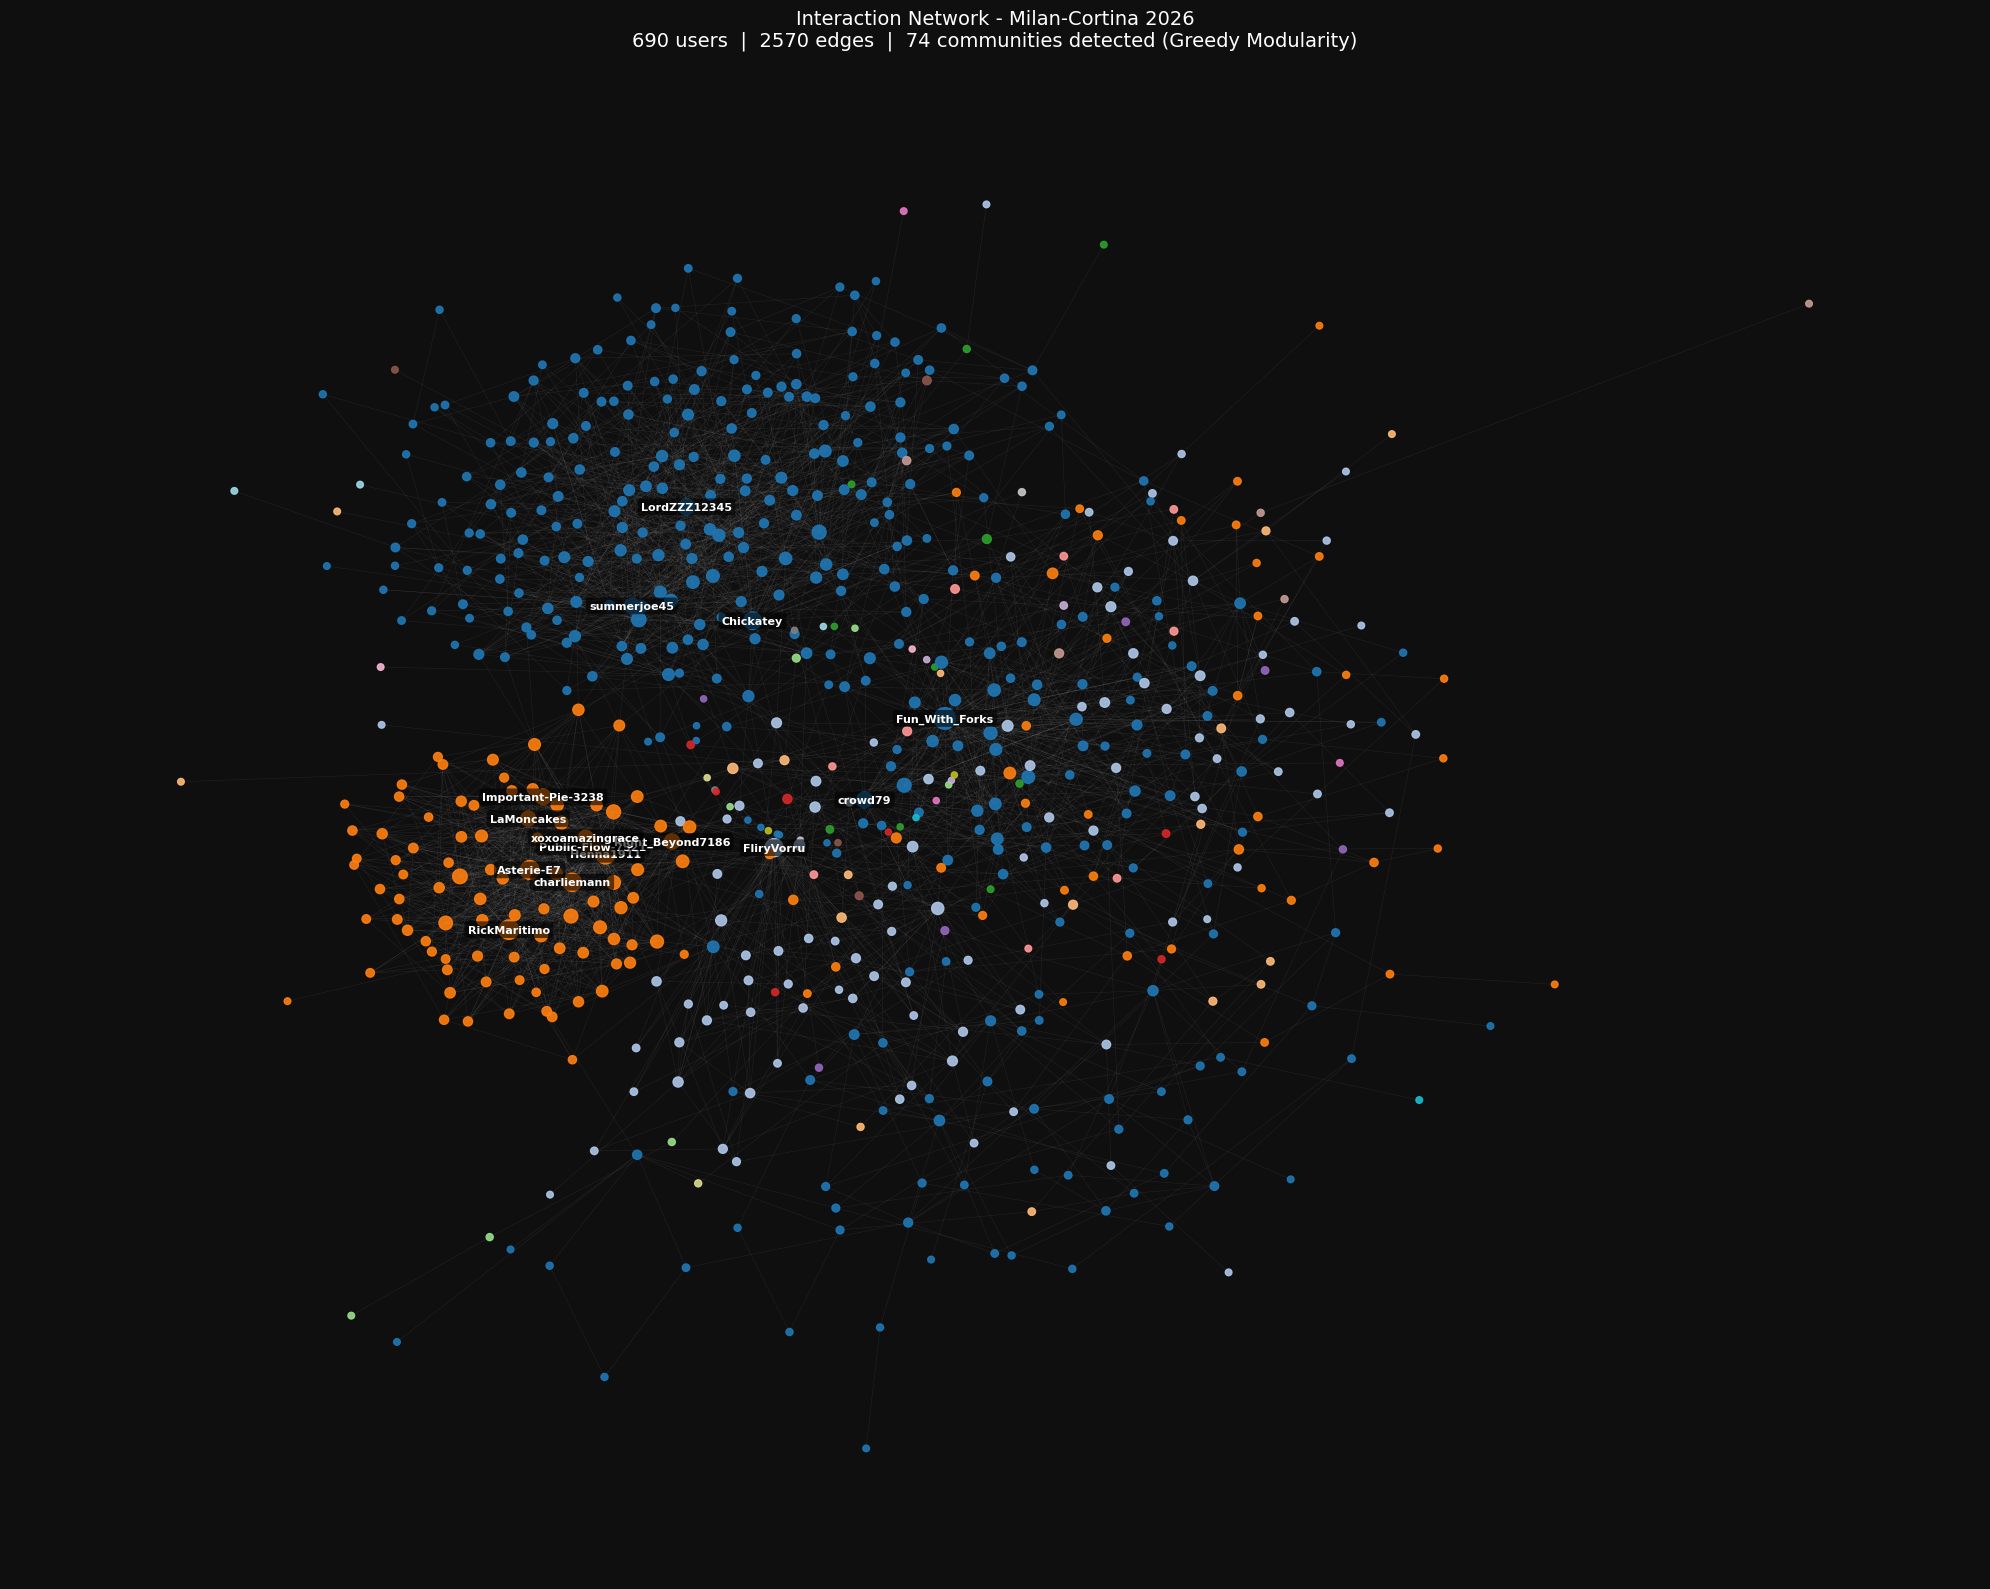

Saved: network_communities.png


In [ ]:
degree_threshold = 8
nodes_to_show = [n for n in G_main.nodes() if G_main.degree(n) >= degree_threshold]
G_viz = G_main.subgraph(nodes_to_show).copy()
print(f'Nodes in the reduced graph: {G_viz.number_of_nodes()}')

communities_present = sorted(set(partition.get(n) for n in G_viz.nodes() if n in partition))
cmap = plt.cm.get_cmap('tab20', len(communities_present))
color_map = {c: cmap(i) for i, c in enumerate(communities_present)}
node_colors = [color_map.get(partition.get(n, 0), 'grey') for n in G_viz.nodes()]

degrees = dict(G_viz.degree())
node_sizes = [20 + degrees[n] * 3 for n in G_viz.nodes()]

pos = nx.kamada_kawai_layout(G_viz, weight='weight')

fig, ax = plt.subplots(figsize=(20, 16))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

nx.draw_networkx_edges(
    G_viz, pos,
    alpha=0.08, width=0.4,
    edge_color='white', ax=ax
)

nx.draw_networkx_nodes(
    G_viz, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9, ax=ax
)

top15 = sorted(G_viz.nodes(), key=lambda n: G_viz.degree(n), reverse=True)[:15]
labels = {n: n for n in top15}

nx.draw_networkx_labels(
    G_viz, pos, labels,
    font_size=8,
    font_color='white',
    font_weight='bold',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='black',
        alpha=0.6,
        edgecolor='none'
    ),
    ax=ax
)

ax.set_title(
    f'Interaction Network - Milan-Cortina 2026\n'
    f'{G_viz.number_of_nodes()} users  |  {G_viz.number_of_edges()} edges  |  '
    f'{num_communities} communities detected (Greedy Modularity)',
    fontsize=14, color='white', pad=20
)

ax.axis('off')
plt.tight_layout()

plt.savefig(
    f'{VIZ_DIR}/network_communities.png',
    dpi=180,
    bbox_inches='tight',
    facecolor='#0f0f0f'
)

plt.show()

print('Saved: network_communities.png')


### Community Heatmap

A heatmap is generated to visualize the distribution of subreddits across the largest communities.

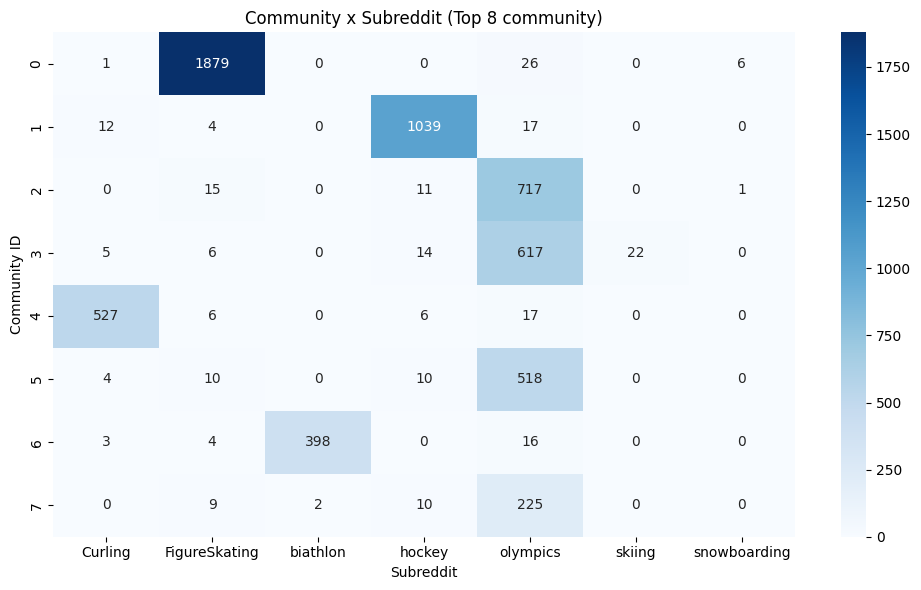

Saved: community_subreddit_heatmap.png


In [ ]:
top8_ids = [c for c, _ in comm_sizes.most_common(8)]
heatmap_data = comm_sub.loc[[c for c in top8_ids if c in comm_sub.index]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Community x Subreddit (Top 8 community)')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Community ID')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/community_subreddit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: community_subreddit_heatmap.png')

### Network Summary

This final section prints a summary of the network, including:
- total number of nodes
- total number of edges
- graph density

In [ ]:
print(f'Total knots         : {G.number_of_nodes()}')
print(f'Total arches         : {G.number_of_edges()}')
print(f'Graph density       : {nx.density(G):.6f}')
print(f'Modularity           : {modularity:.4f}')
print(f'Communities detected   : {num_communities}')
print(f'Main Comp. Nodes: {G_main.number_of_nodes()}')
print('\nTop 5 users by PageRank:')
print(centrality_df[['user', 'pagerank', 'in_degree', 'betweenness']].head(5).to_string(index=False))

Total knots         : 8698
Total arches         : 16996
Graph density       : 0.000225
Modularity           : 0.7920
Communities detected   : 74
Main Comp. Nodes: 8372

Top 5 users by PageRank:
                user  pagerank  in_degree  betweenness
      Fun_With_Forks  0.028318       1185     0.145436
          FliryVorru  0.019700        449     0.094413
 SpiritualWatermelon  0.012707          6     0.000134
Chemical-Ocelot-9105  0.009582         26     0.001743
           Chickatey  0.009386        299     0.081748
